# M4 — Leveraging, Hedging and Portfolio Risk:
## A Geometric and Optimization-Based Analysis of Affine Portfolio Allocation

COE745 — Linear Algebra, Optimization and Data-Driven Control

| Name | Academic Position |
|---|---|
| Bismark Brandi Sigolo | M.Sc. Student in Robotics Engineering |
| Jonas Tobias Ulbrich | Ph.D. Student in Robotics Engineering |
| Rickson Gomes Monteiro | M.Sc. Student in Robotics Engineering |

# 1. Introduction

Portfolio allocation problems constitute one of the most fundamental applications of linear algebra, optimization, and statistical modeling in finance. At their core, portfolios can be interpreted as affine combinations of assets, where allocation parameters determine the tradeoff between expected return and financial risk.

In modern portfolio theory, risk is commonly quantified through the statistical variance or standard deviation of returns, while expected return measures the average gain associated with an investment strategy. The interaction between these quantities gives rise to the classical risk-return tradeoff, a central concept in quantitative finance and optimization.

In this project, we investigate a simplified portfolio composed of:

- a risky asset represented by a temporal return series;
- and a risk-free asset representing cash or money.

The portfolio is parameterized by a scalar allocation coefficient $\theta$, which controls the exposure level to the risky asset. Different values of $\theta$ naturally lead to distinct financial strategies:

- **hedging**, when exposure to the risky asset is reduced;
- **leveraging**, when borrowed capital is used to amplify exposure;
- **short-selling**, when the investor assumes negative exposure to the asset.

Although the problem appears financial in nature, its mathematical structure is fundamentally geometric and algebraic. In particular, the portfolio family can be interpreted as an affine subspace in the vector space of temporal returns, while portfolio risk emerges as a quadratic form associated with the energy of the centered return signal.

From a linear algebra perspective, the portfolio dynamics are governed by:

- affine transformations;
- vector scaling;
- quadratic norms;
- variance propagation;
- and geometric projections.

Furthermore, the problem establishes important connections with:

- convex optimization,
- least squares geometry,
- signal energy interpretation,
- and the geometric structure of statistical spaces.

The main objective of this work is to derive analytical expressions for the expected return and risk of the portfolio, analyze the effects of leveraging and short-selling, and provide both geometric and computational interpretations of the resulting allocation strategies.

Additionally, numerical simulations are performed to illustrate how the allocation parameter $\theta$ modifies:

- portfolio volatility,
- expected return,
- temporal behavior,
- and the geometry of the risk-return space.

This project therefore connects concepts from financial mathematics, optimization, and linear algebra through a mathematical and computational framework.

# 2. Original Problem Statement

Consider a risky asset whose temporal return series over \(T\) periods is represented by the vector

$$
r \in \mathbb{R}^T.
$$

Let:

- $mu$ denote the average return of the asset;
- $\sigma > 0$ denote its standard deviation (risk).

We model money (cash) as a risk-free asset with return vector:

$$
u_d \mathbf{1},
$$

where:

- $u_d$ is the deterministic return of the risk-free asset;
- $\mathbf{1} \in \mathbb{R}^T$ is the all-ones vector.

We construct a simple portfolio composed of the risky asset and money. If a fraction $\theta$ of the portfolio is invested in the risky asset and the remaining fraction $(1-\theta)$ is invested in cash, then the portfolio return vector is given by

$$
c
=
\theta r
+
(1-\theta)u_d\mathbf{1}.
$$

The allocation parameter $\theta$ is unrestricted:

- $\theta > 1$: leveraging (borrowing money to buy more of the risky asset);
- $\theta < 0$: short-selling the risky asset;
- $0 < \theta < 1$: hedging through mixed allocation between the risky asset and cash.

The objectives are:

1. Derive formulas for:
   - the expected return of the portfolio;
   - the portfolio risk (standard deviation);

in terms of:

$$
\mu,\sigma,u_d,\theta.
$$

2. Explain how to choose $\theta$ such that the portfolio achieves a target risk level:

$$
\sigma_{target} > 0.
$$

3. If multiple values of $\theta$ achieve the target risk, determine which one maximizes expected return.

4. Explain under which conditions:
   - leveraging,
   - short-selling,
   - and hedging

should be used.

Source:  
COE745 — Mini-Projects (M4: Leveraging)

## 2.1 Expected Portfolio Return and Risk

## a) Expected Portfolio Return

The average return of the portfolio can be interpreted as the expected value of the portfolio return, considering the portfolio as a random variable.

Therefore, the portfolio expected return is obtained by taking the expectation operator over the portfolio vector \(c\). Thus, we have:

$$
\mu_c
=
\mathbb{E}[c].
$$

Using the portfolio definition,

$$
c
=
\theta r
+
(1-\theta)u_d\mathbf{1},
$$

we obtain:

$$
\mu_c
=
\mathbb{E}
\left[
\theta r
+
(1-\theta)u_d\mathbf{1}
\right].
$$

Observe that the terms $\theta$ and $(1-\theta)u_d$ are scalar constants. Therefore, by the **linearity property of the expectation operator**, namely,

$$
\mathbb{E}[aX+bY]
=
a\mathbb{E}[X]
+
b\mathbb{E}[Y],
$$

we can rewrite the expression as:

$$
\mu_c
=
\theta \mathbb{E}[r]
+
(1-\theta)u_d \mathbb{E}[\mathbf{1}].
$$

Since:

$$
\mathbb{E}[r] = \mu
\quad\text{and}\quad
\mathbb{E}[\mathbf{1}] = 1,
$$

it follows that the expected portfolio return is:

$$
\boxed{
\mu_c
=
\theta \mu
+
(1-\theta)u_d
}
$$

This expression shows that the portfolio expected return is an affine interpolation between:

- the risky asset return $\mu$,
- and the risk-free return $u_d$,

parameterized by the allocation coefficient $\theta$.

### b) Portfolio Variance and Risk

The portfolio risk is quantified through the variance (or equivalently, the standard deviation) of the portfolio returns.

Recall that the portfolio return vector is given by:

$$
c
=
\theta r
+
(1-\theta)u_d\mathbf{1}.
$$

The variance of the portfolio is defined as:

$$
\mathrm{Var}(c)
=
\mathbb{E}
\left[
(c-\mu_c)^2
\right],
$$

where:

- $(\mu_c)$ denotes the expected portfolio return;
- $(c-\mu_c)$ represents the centered portfolio return.

From the previous derivation, the expected portfolio return is:

$$
\mu_c = 
\theta\mu + (1-\theta)u_d.
$$

Substituting the expressions for (c) and $(\mu_c)$, we obtain:

$$
c-\mu_c
=
\left(
\theta r
+
(1-\theta)u_d\mathbf{1}
\right)
-
\left(
\theta\mu
+
(1-\theta)u_d
\right).
$$

Observe that the term:

$$
(1-\theta)u_d\mathbf{1}
-
(1-\theta)u_d
$$

vanishes because:

$$
\mathbb{E}[\mathbf{1}] = 1,
$$

under the expectation operator and centering process. Therefore:

$$
c-\mu_c
=
\theta(r-\mu).
$$

Substituting this result into the variance definition:

$$
\mathrm{Var}(c)
=
\mathbb{E}
\left[
(\theta(r-\mu))^2
\right].
$$

Since $(\theta)$ is a scalar constant, we use the homogeneity property of the expectation operator:

$$
\mathbb{E}[a^2X]
=
a^2\mathbb{E}[X],
$$

which yields:

$$
\mathrm{Var}(c)
=
\theta^2
\mathbb{E}
\left[
(r-\mu)^2
\right].
$$

Recognizing that:

$$
\mathbb{E}
\left[
(r-\mu)^2
\right]
=
\sigma^2,
$$

we conclude that the portfolio variance is:

$$
\boxed{
\mathrm{Var}(c)
=
\theta^2\sigma^2
}
$$

Taking the square root of both sides, the portfolio standard deviation (risk) becomes:

$$
\boxed{
\sigma_c
=
|\theta|\sigma
}
$$


### Interpretation

This result reveals a fundamental property of the portfolio dynamics:

- the portfolio risk scales linearly with the magnitude of the allocation parameter $\theta$.

Consequently:

- if $(0 < \theta < 1)$, the portfolio risk is reduced (hedging);
- if $(\theta > 1)$, the portfolio risk is amplified (leveraging);
- if $(\theta < 0)$, the portfolio assumes inverse exposure to the risky asset (short-selling).


### Geometric Interpretation

From a geometric perspective, the centered return vector:

$$
r-\mu
$$

defines a direction in the return space.

The allocation parameter $\theta$ acts as a scaling factor along this direction. Since variance corresponds to the quadratic energy of the centered vector, scaling the vector by $\theta$ causes:

$$
\mathrm{Var}(c)
\propto
\theta^2,
$$

while the standard deviation scales proportionally to:

$$
|\theta|.
$$

Thus, portfolio risk can be interpreted as the Euclidean magnitude of the centered portfolio vector in the return space.

## 2.2 Choosing $\theta$ for a Target Risk Level

Suppose the objective is to construct a portfolio whose risk equals a desired target level:

$$
\sigma_{target} > 0.
$$

From the previous derivation, the portfolio risk is given by:

$$
\sigma_c
=
|\theta|\sigma,
$$

where:

- $\sigma_c$ is the portfolio standard deviation;
- $\sigma$ is the standard deviation of the risky asset.

To achieve the target risk level, we impose:

$$
\sigma_c
=
\sigma_{target}.
$$

Substituting the expression for the portfolio risk:

$$
|\theta|\sigma
=
\sigma_{target}.
$$

Assuming:

$$
\sigma > 0,
$$

we divide both sides by $\sigma$:

$$
|\theta|
=
\frac{\sigma_{target}}{\sigma}.
$$

Therefore, the possible allocation coefficients are:

$$
\boxed{
\theta
=
\pm
\frac{\sigma_{target}}{\sigma}
}
$$

This result reveals that, in general, there are two possible portfolio allocations capable of achieving the same target risk level:


### Positive Solution

$$
\theta
=
+
\frac{\sigma_{target}}{\sigma}
$$

This corresponds to:

- standard exposure to the risky asset;
- leveraging if $(\theta > 1)$.


### Negative Solution

$$
\theta
=
-
\frac{\sigma_{target}}{\sigma}
$$

This corresponds to:

- short-selling the risky asset;
- inverse market exposure.


## Geometric Interpretation

The result:

$$
\sigma_c
=
|\theta|\sigma
$$

shows that portfolio risk scales linearly with the magnitude of the allocation parameter $\theta$.

Geometrically, scaling the portfolio by $\theta$ scales the centered return vector proportionally in Euclidean space, causing the variance (quadratic energy) to scale by $\theta^2$, and consequently the standard deviation to scale by $(|\theta|)$.

Thus, the target-risk problem reduces to selecting an appropriate scaling factor along the affine portfolio direction.

## 2.3 Maximum Return Under a Target Risk Constraint

From the previous derivation, the portfolio risk is given by:

$$
\sigma_c
=
|\theta|\sigma.
$$

Suppose the portfolio must satisfy a target risk level:

$$
\sigma_c
=
\sigma_{target}.
$$

Solving for \(\theta\), we obtained:

$$
\theta
=
\pm
\frac{\sigma_{target}}{\sigma}.
$$

Therefore, two different portfolio allocations generally satisfy the same risk constraint:

$$
\theta_+
=
+
\frac{\sigma_{target}}{\sigma}
\quad\text{and}\quad
\theta_-
=
-
\frac{\sigma_{target}}{\sigma}.
$$

The question now becomes:

> Which allocation produces the maximum expected return?

---

Recall that the portfolio expected return is:

$$
\mu_c
=
\theta\mu
+
(1-\theta)u_d.
$$

Rearranging the expression:

$$
\mu_c
=
u_d
+
\theta(\mu-u_d).
$$

Substituting the positive allocation:

$$
\mu_c^{(+)}
=
u_d
+
\frac{\sigma_{target}}{\sigma}
(\mu-u_d),
$$

and substituting the negative allocation:

$$
\mu_c^{(-)}
=
u_d
-
\frac{\sigma_{target}}{\sigma}
(\mu-u_d).
$$

To determine which allocation yields the maximum expected return, we analyze the sign of:

$$
\mu-u_d.
$$

---

## Case 1 — Risky Asset Outperforms the Risk-Free Asset

If:

$$
\mu > u_d,
$$

then:

$$
\mu-u_d > 0.
$$

In this case:

$$
\mu_c^{(+)}
>
\mu_c^{(-)}.
$$

Therefore, the portfolio with:

$$
\boxed{
\theta
=
+
\frac{\sigma_{target}}{\sigma}
}
$$

produces the maximum expected return.

This corresponds to:

- positive exposure to the risky asset;
- leveraging when \(\theta > 1\).

---

## Case 2 — Risky Asset Underperforms the Risk-Free Asset

If:

$$
\mu < u_d,
$$

then:

$$
\mu-u_d < 0.
$$

Consequently:

$$
\mu_c^{(-)}
>
\mu_c^{(+)}.
$$

Thus, the portfolio with:

$$
\boxed{
\theta
=
-
\frac{\sigma_{target}}{\sigma}
}
$$

produces the maximum expected return.

This corresponds to:

- short-selling the risky asset;
- allocating capital against the asset direction.

---

## Case 3 — Equal Returns

If:

$$
\mu = u_d,
$$

then:

$$
\mu_c^{(+)}
=
\mu_c^{(-)}
=
u_d.
$$

In this situation, both allocations produce the same expected return.

---

## Final Result

The allocation maximizing expected return under a fixed risk level is determined by comparing:

$$
\mu
\quad\text{and}\quad
u_d.
$$

Therefore:

$$
\boxed{
\begin{cases}
\theta > 0, & \text{if } \mu > u_d, \\
\\
\theta < 0, & \text{if } \mu < u_d.
\end{cases}
}
$$

---

## Geometric Interpretation

The expected portfolio return:

$$
\mu_c
=
u_d
+
\theta(\mu-u_d)
$$

defines an affine line in the risk-return plane.

The two admissible values of $(\theta)$ correspond to two opposite directions along this affine manifold.

The optimal choice corresponds to selecting the direction that maximizes displacement toward larger expected return values while maintaining the same Euclidean risk magnitude.

## 2.4 When Should Leveraging, Short-Selling and Hedging Be Used?

The choice of the allocation parameter $(\theta)$ determines the investor’s exposure to the risky asset and directly affects both the portfolio return and its associated risk.

Different ranges of $(\theta)$ correspond to distinct financial strategies, each appropriate under specific market conditions and investment objectives.

---

## Hedging

Hedging occurs when:

$$
0 < \theta < 1.
$$

In this regime, only a fraction of the capital is invested in the risky asset, while the remaining portion is allocated to the risk-free asset.

Hedging should be used when:

- the investor seeks to reduce portfolio volatility;
- capital preservation is important;
- market uncertainty is high;
- or the investor prefers lower exposure to fluctuations in the risky asset.

From a mathematical perspective, hedging reduces the magnitude of the centered portfolio vector, thereby decreasing the variance:

$$
\sigma_c
=
|\theta|\sigma.
$$

Geometrically, the portfolio moves closer to the risk-free direction in the return space.

---

## Leveraging

Leveraging occurs when:

$$
\theta > 1.
$$

In this case, the investor borrows additional capital to increase exposure to the risky asset.

Leveraging should be used when:

- the risky asset is expected to significantly outperform the risk-free asset;
- the investor accepts higher volatility in exchange for higher expected return;
- or strong positive market trends are anticipated.

Since:

$$
\sigma_c
=
|\theta|\sigma,
$$

leveraging amplifies both:

- expected return,
- and portfolio risk.

Thus, although leverage can substantially increase gains, it also magnifies losses and financial instability.

Geometrically, leveraging corresponds to extending the portfolio farther along the risky asset direction in the affine portfolio manifold.

---

## Short-Selling

Short-selling occurs when:

$$
\theta < 0.
$$

In this situation, the investor assumes negative exposure to the risky asset, profiting when the asset value decreases.

Short-selling should be used when:

- the risky asset is expected to underperform the risk-free asset;
- negative market behavior is anticipated;
- or the investor seeks inverse exposure to the asset dynamics.

From the expected return expression:

$$
\mu_c
=
u_d
+
\theta(\mu-u_d),
$$

negative values of $(\theta)$ become advantageous whenever:

$$
\mu < u_d.
$$

Geometrically, short-selling reverses the portfolio direction in the return space, producing an inverse exposure relative to the risky asset.

---

## Final Interpretation

The allocation parameter $(\theta)$ acts as a scaling and orientation coefficient in the portfolio space:

- its magnitude controls the portfolio risk level;
- its sign determines the exposure direction relative to the risky asset.

Therefore:

- hedging reduces exposure;
- leveraging amplifies exposure;
- short-selling reverses exposure.

The appropriate strategy depends fundamentally on:

- the relationship between $(\mu)$ and $(u_d)$,
- market expectations,
- and the investor’s tolerance to risk.

# 3. Computational Simulations and Numerical Experiments

The following sections present computational implementations and numerical simulations related to the analytical results derived previously.

The main objective of these experiments is to validate the mathematical derivations associated with:

- portfolio expected return;
- portfolio risk scaling;
- target-risk allocation;
- leveraging;
- hedging;
- and short-selling strategies.

Additionally, the simulations aim to provide:

- geometric interpretation of portfolio allocation;
- statistical visualization of return distributions;
- and numerical evidence of the affine structure of the portfolio space.

Through graphical analysis and numerical experiments, we investigate how the allocation parameter \(\theta\) modifies:

- portfolio volatility;
- expected return;
- temporal dynamics;
- and the geometry of the risk-return relationship.

In [5]:
#imports

import numpy as np
import matplotlib.pyplot as plt

## A) Risk-Return Curve (Capital Allocation Line)

### Introduction

In this section, we analyze the relationship between portfolio risk and expected return as the allocation parameter \(\theta\) varies.

The objective is to numerically verify the analytical expressions:

$$
\mu_c
=
\theta\mu
+
(1-\theta)u_d
$$

and

$$
\sigma_c
=
|\theta|\sigma.
$$

The simulation investigates how different allocation regimes modify the portfolio behavior, including:

- hedging;
- leveraging;
- and short-selling strategies.

The resulting graph illustrates the geometric structure of the portfolio family in the risk-return plane.

In particular, the figure highlights:

- the risk-free asset;
- the risky asset;
- and the affine portfolio trajectories generated by different values of \(\theta\).

Additionally, the graph reveals the symmetric risk behavior induced by the absolute value relationship in:

$$
\sigma_c
=
|\theta|\sigma,
$$

which produces distinct branches associated with positive and negative portfolio exposures.

This geometric structure is closely related to the classical Capital Allocation Line (CAL) in portfolio theory.

In [21]:
np.random.seed(42)

T = 300
mu = 0.0015
sigma = 0.02

r = np.random.normal(mu, sigma, T) # Simulated risky asset returns
ud = 0.0003 # Risk-free return
theta_values = np.linspace(-2, 2, 500) # Allocation Parameter Range

portfolio_returns = []
portfolio_risks = []


for theta in theta_values:
    mu_c = theta * mu + (1 - theta) * ud # Portfolio expected return
    sigma_c = abs(theta) * sigma # Portfolio risk

    portfolio_returns.append(mu_c)
    portfolio_risks.append(sigma_c)

portfolio_returns = np.array(portfolio_returns)
portfolio_risks = np.array(portfolio_risks)

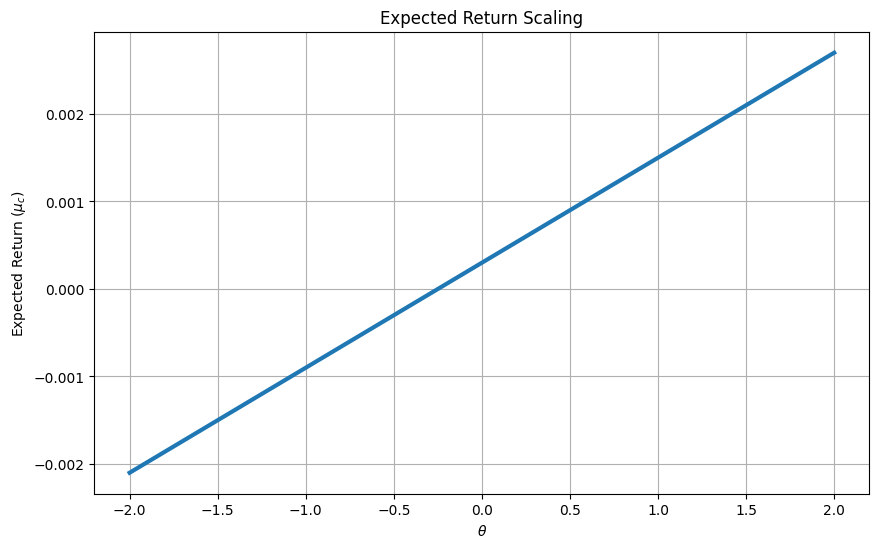

In [26]:
mu_values = []

for theta in theta_values:
    mu_c = theta*mu + (1-theta)*ud
    mu_values.append(mu_c)

plt.figure(figsize=(10,6))
plt.plot(theta_values, mu_values, linewidth=3)

plt.xlabel(r"$\theta$")
plt.ylabel(r"Expected Return $(\mu_c)$")
plt.title("Expected Return Scaling")

plt.grid(True)
plt.show()

The figure confirms that the portfolio expected return varies linearly with respect to the allocation parameter \(\theta\).

Geometrically, the graph represents an affine transformation between the risky asset return and the risk-free return.

Positive values of \(\theta\) increase exposure to the risky asset, while negative values correspond to inverse exposure through short-selling.

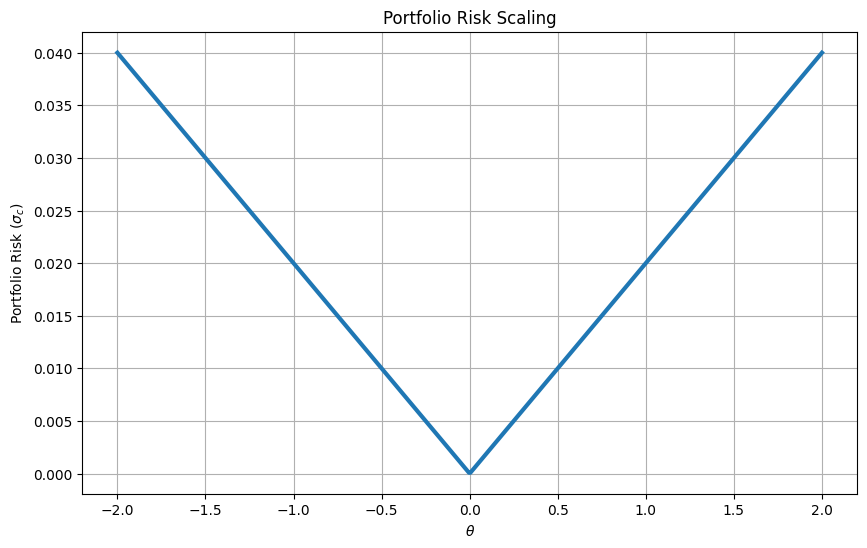

In [23]:
sigma_values = []

for theta in theta_values:
    sigma_c = abs(theta)*sigma
    sigma_values.append(sigma_c)

plt.figure(figsize=(10,6))
plt.plot(theta_values, sigma_values, linewidth=3)

plt.xlabel(r"$\theta$")
plt.ylabel(r"Portfolio Risk $(\sigma_c)$")
plt.title("Portfolio Risk Scaling")

plt.grid(True)
plt.show()

The graph reveals that the portfolio risk scales proportionally to the magnitude of the allocation parameter.

The absolute value operation produces a symmetric structure, implying that positive and negative exposures may generate the same risk level.

This symmetry explains the existence of two distinct branches in the risk-return plane.

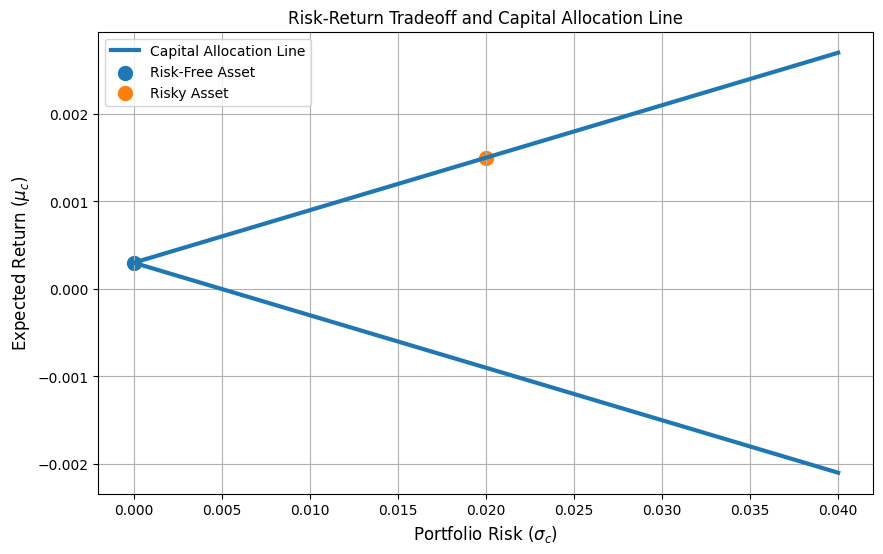

In [25]:
plt.figure(figsize=(10,6))

plt.plot(
    portfolio_risks,
    portfolio_returns,
    linewidth=3,
    label="Capital Allocation Line"
)

# Risk-free asset point
plt.scatter(
    0,
    ud,
    s=100,
    label="Risk-Free Asset"
)

# Risky asset point
plt.scatter(
    sigma,
    mu,
    s=100,
    label="Risky Asset"
)

plt.xlabel("Portfolio Risk ($\\sigma_c$)", fontsize=12)
plt.ylabel("Expected Return ($\\mu_c$)", fontsize=12)
plt.title("Risk-Return Tradeoff and Capital Allocation Line")

plt.grid(True)
plt.legend()
plt.show()

### Numerical Interpretation

The numerical results confirm the analytical expressions derived previously for both the portfolio expected return and portfolio risk.

The figure highlights two fundamental reference points in the risk-return plane:

- the **Risk-Free Asset**, located at

$$
(0,u_d),
$$

representing zero risk and deterministic return;

- and the **Risky Asset**, located at

$$
(\sigma,\mu),
$$

corresponding to full exposure to the risky asset (\(\theta=1\)).

Geometrically, these two points define the affine direction along which the entire portfolio family is generated.

The graph further reveals that the portfolio family forms two distinct linear branches:

- an upper branch associated with positive allocations (\(\theta>0\));
- and a lower branch associated with negative allocations (\(\theta<0\)).

This bifurcation emerges directly from:

$$
\sigma_c
=
|\theta|\sigma,
$$

which implies that positive and negative exposures may generate the same risk magnitude while producing opposite return behaviors.

The upper branch corresponds to:

- standard exposure to the risky asset;
- and leveraged strategies when \(\theta>1\).

The lower branch corresponds to:

- short-selling strategies,
- where the portfolio assumes inverse exposure to the risky asset.

From a geometric perspective, the simulation demonstrates that the set of admissible portfolios forms a one-dimensional affine manifold in the risk-return space, parameterized by the allocation coefficient \(\theta\).

The experiment therefore provides numerical evidence for:

- affine portfolio geometry;
- linear expected return scaling;
- symmetric variance behavior;
- and the geometric structure of leverage and short-selling strategies.

## B) Variance Scaling with Respect to the Allocation Parameter

### Introduction

This section investigates how the portfolio variance evolves as a function of the allocation parameter \(\theta\).

The objective is to numerically validate the quadratic scaling law:

$$
\mathrm{Var}(c)
=
\theta^2\sigma^2.
$$

From a geometric perspective, this experiment demonstrates how scaling the centered return vector modifies the quadratic energy associated with the portfolio.

In [31]:
theta_values = np.linspace(-2, 2, 500)
portfolio_variances = []

for theta in theta_values:
    variance_c = (theta**2) * (sigma**2) # Theoretical portfolio variance
    portfolio_variances.append(variance_c)

portfolio_variances = np.array(portfolio_variances)

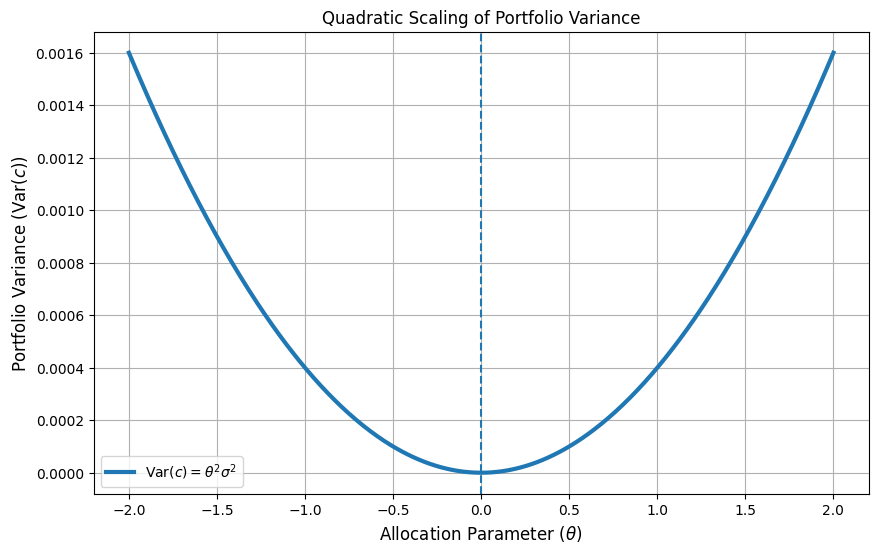

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    theta_values,
    portfolio_variances,
    linewidth=3,
    label=r'$\mathrm{Var}(c)=\theta^2\sigma^2$'
)

plt.axvline(
    x=0,
    linestyle='--',
    linewidth=1.5
)

plt.xlabel(r'Allocation Parameter $(\theta)$', fontsize=12)
plt.ylabel(r'Portfolio Variance $(\mathrm{Var}(c))$', fontsize=12)

plt.title("Quadratic Scaling of Portfolio Variance")
plt.grid(True)
plt.legend()

plt.show()

### Numerical Interpretation

The simulation confirms that the portfolio variance evolves quadratically with respect to the allocation parameter $(\theta)$.

The parabolic structure observed in the figure emerges directly from the quadratic relationship:

$$
\mathrm{Var}(c)
=
\theta^2\sigma^2.
$$

An important consequence of this behavior is the symmetry around:

$$
\theta = 0,
$$

which implies that:

- positive and negative portfolio exposures produce the same variance magnitude;
- variance depends only on the exposure magnitude, not on its direction.

From a financial perspective:

- hedging $(0 < |\theta| < 1)$ reduces portfolio volatility;
- leveraging $(|\theta| > 1)$ rapidly amplifies risk;
- and short-selling $(\theta < 0)$ preserves variance magnitude while reversing exposure direction.

Geometrically, the experiment demonstrates that variance behaves as a quadratic energy functional in the return space.

Scaling the centered return vector by $(\theta)$ increases its Euclidean energy proportionally to:

$$
\theta^2,
$$

which explains the parabolic structure observed in the graph.

## C) Portfolio Time-Series Dynamics

### Introduction

In this section, we compare the temporal evolution of different portfolio strategies, including:

- hedging,
- leveraging,
- and short-selling.

The objective is to visualize how the allocation parameter $(\theta)$ transforms the original return signal over time.

This experiment provides an intuitive interpretation of portfolio allocation as an affine transformation acting on the return series.

In [40]:
np.random.seed(42)

T = 300
mu = 0.0015
sigma = 0.02

r = np.random.normal(mu, sigma, T)
ud = 0.0003

# Portfolio Configurations
theta_values = {
    "Hedging ($\\theta=0.5$)": 0.5,
    "Original Asset ($\\theta=1$)": 1.0,
    "Leveraging ($\\theta=2$)": 2.0,
    "Short-Selling ($\\theta=-1$)": -1.0
}

portfolio_series = {}

for label, theta in theta_values.items():
    c = theta * r + (1 - theta) * ud
    portfolio_series[label] = c

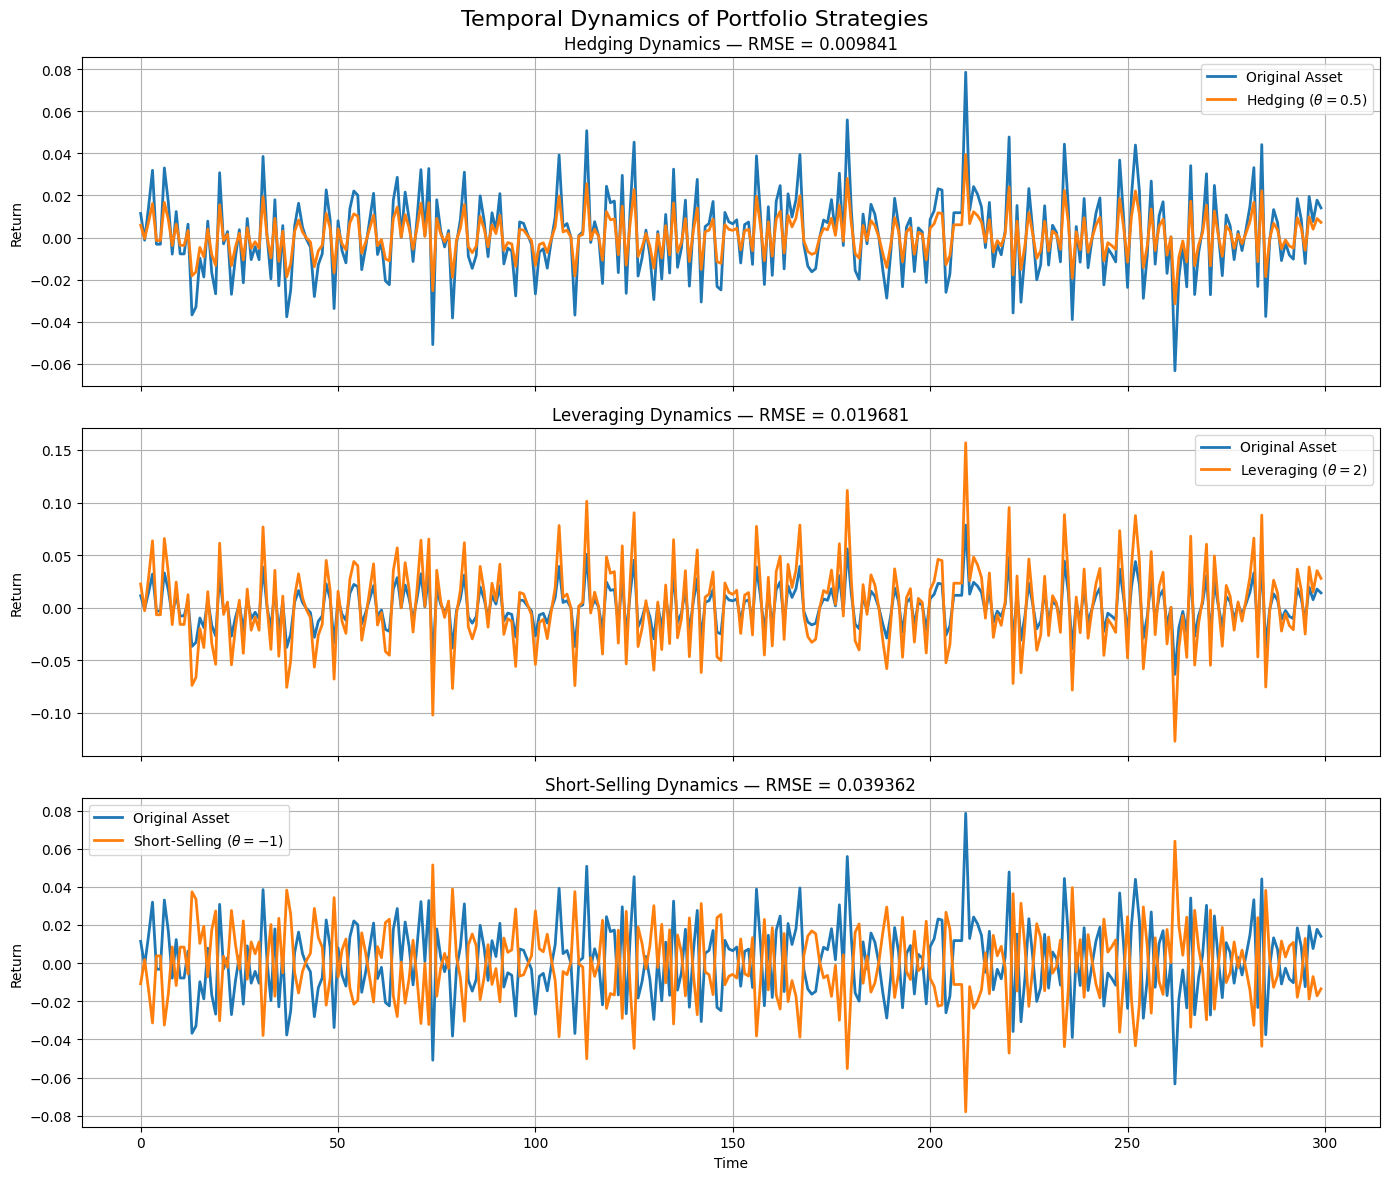

In [ ]:
rmse_hedging = np.sqrt(
    np.mean(
        (
            r -
            portfolio_series["Hedging ($\\theta=0.5$)"]
        )**2
    )
)

rmse_leveraging = np.sqrt(
    np.mean(
        (
            r -
            portfolio_series["Leveraging ($\\theta=2$)"]
        )**2
    )
)

rmse_short = np.sqrt(
    np.mean(
        (
            r -
            portfolio_series["Short-Selling ($\\theta=-1$)"]
        )**2
    )
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14,12),
    sharex=True
)

axes[0].plot(
    r,
    linewidth=2,
    label='Original Asset'
)
axes[0].plot(
    portfolio_series["Hedging ($\\theta=0.5$)"],
    linewidth=2,
    label='Hedging ($\\theta=0.5$)'
)
axes[0].set_title(
    f"Hedging Dynamics — RMSE = {rmse_hedging:.6f}"
)

axes[0].set_ylabel("Return")
axes[0].grid(True)
axes[0].legend()


axes[1].plot(
    r,
    linewidth=2,
    label='Original Asset'
)

axes[1].plot(
    portfolio_series["Leveraging ($\\theta=2$)"],
    linewidth=2,
    label='Leveraging ($\\theta=2$)'
)

axes[1].set_title(
    f"Leveraging Dynamics — RMSE = {rmse_leveraging:.6f}"
)

axes[1].set_ylabel("Return")
axes[1].grid(True)
axes[1].legend()


axes[2].plot(
    r,
    linewidth=2,
    label='Original Asset'
)

axes[2].plot(
    portfolio_series["Short-Selling ($\\theta=-1$)"],
    linewidth=2,
    label='Short-Selling ($\\theta=-1$)'
)

axes[2].set_title(
    f"Short-Selling Dynamics — RMSE = {rmse_short:.6f}"
)

axes[2].set_xlabel("Time")
axes[2].set_ylabel("Return")
axes[2].grid(True)
axes[2].legend()


fig.suptitle(
    "Temporal Dynamics of Portfolio Strategies",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Numerical Interpretation

The simulations demonstrate how different portfolio allocation strategies modify the temporal dynamics of the original return signal.

The Root Mean Squared Error (RMSE) was used as a quantitative metric to measure the deviation between the original asset returns and the transformed portfolio returns.

Mathematically, the RMSE is defined as:

$$
\mathrm{RMSE}(r,c)
=
\sqrt{
\frac{1}{T}
\sum_{t=1}^{T}
(r_t-c_t)^2
}.
$$

From a geometric perspective, the RMSE measures the Euclidean distance between the original return vector and the transformed portfolio vector in the return space.

---

## Hedging Dynamics

The hedging strategy produced the smallest RMSE:

$$
\mathrm{RMSE} \approx 0.009841.
$$

This behavior indicates that the hedged portfolio remains relatively close to the original asset dynamics.

Visually, the oscillations become attenuated while preserving the overall temporal structure of the signal.

This result is expected because:

$$
0 < \theta < 1
$$

reduces the amplitude of the return fluctuations without changing their orientation.

Geometrically, the portfolio vector moves toward the risk-free direction while remaining aligned with the original asset.

---

## Leveraging Dynamics

The leveraged portfolio produced a larger RMSE:

$$
\mathrm{RMSE} \approx 0.019681.
$$

The simulation shows a significant amplification of the temporal oscillations relative to the original asset.

This behavior directly reflects the variance scaling law:

$$
\mathrm{Var}(c)
=
\theta^2\sigma^2.
$$

Since:

$$
\theta > 1,
$$

the return fluctuations are amplified proportionally to the leverage magnitude.

From a signal-processing perspective, leverage acts as a gain operator that increases the energy of the temporal return signal.

---

## Short-Selling Dynamics

The short-selling strategy produced the largest RMSE:

$$
\mathrm{RMSE} \approx 0.039362.
$$

Unlike hedging and leveraging, short-selling not only modifies the signal amplitude but also reverses the orientation of the return dynamics.

This inversion causes positive fluctuations in the original asset to become negative fluctuations in the portfolio, and vice versa.

Consequently, the geometric distance between the original and transformed signals becomes substantially larger.

From a vector-space perspective, short-selling corresponds to reflecting the return vector across the origin of the centered return space.

---

## Overall Conclusion

The experiments demonstrate that the allocation parameter $(\theta)$ simultaneously controls:

- volatility magnitude,
- signal amplification,
- and exposure orientation.

The RMSE analysis quantitatively confirms the geometric interpretation developed throughout this work:

- hedging attenuates the signal while preserving its structure;
- leveraging amplifies the signal energy;
- short-selling reverses the signal orientation.

Therefore, portfolio allocation can be interpreted as an affine transformation acting on the temporal return signal, where the parameter $(\theta)$ governs both the magnitude and direction of the portfolio dynamics.

## D) Distribution of Portfolio Returns

### Introduction

This section analyzes the statistical distribution of portfolio returns under different allocation strategies.

The objective is to investigate how leveraging, hedging, and short-selling modify:

- dispersion,
- variability,
- and overall statistical behavior of the returns.

Histogram visualizations are used to compare the probability distribution of different portfolio configurations.

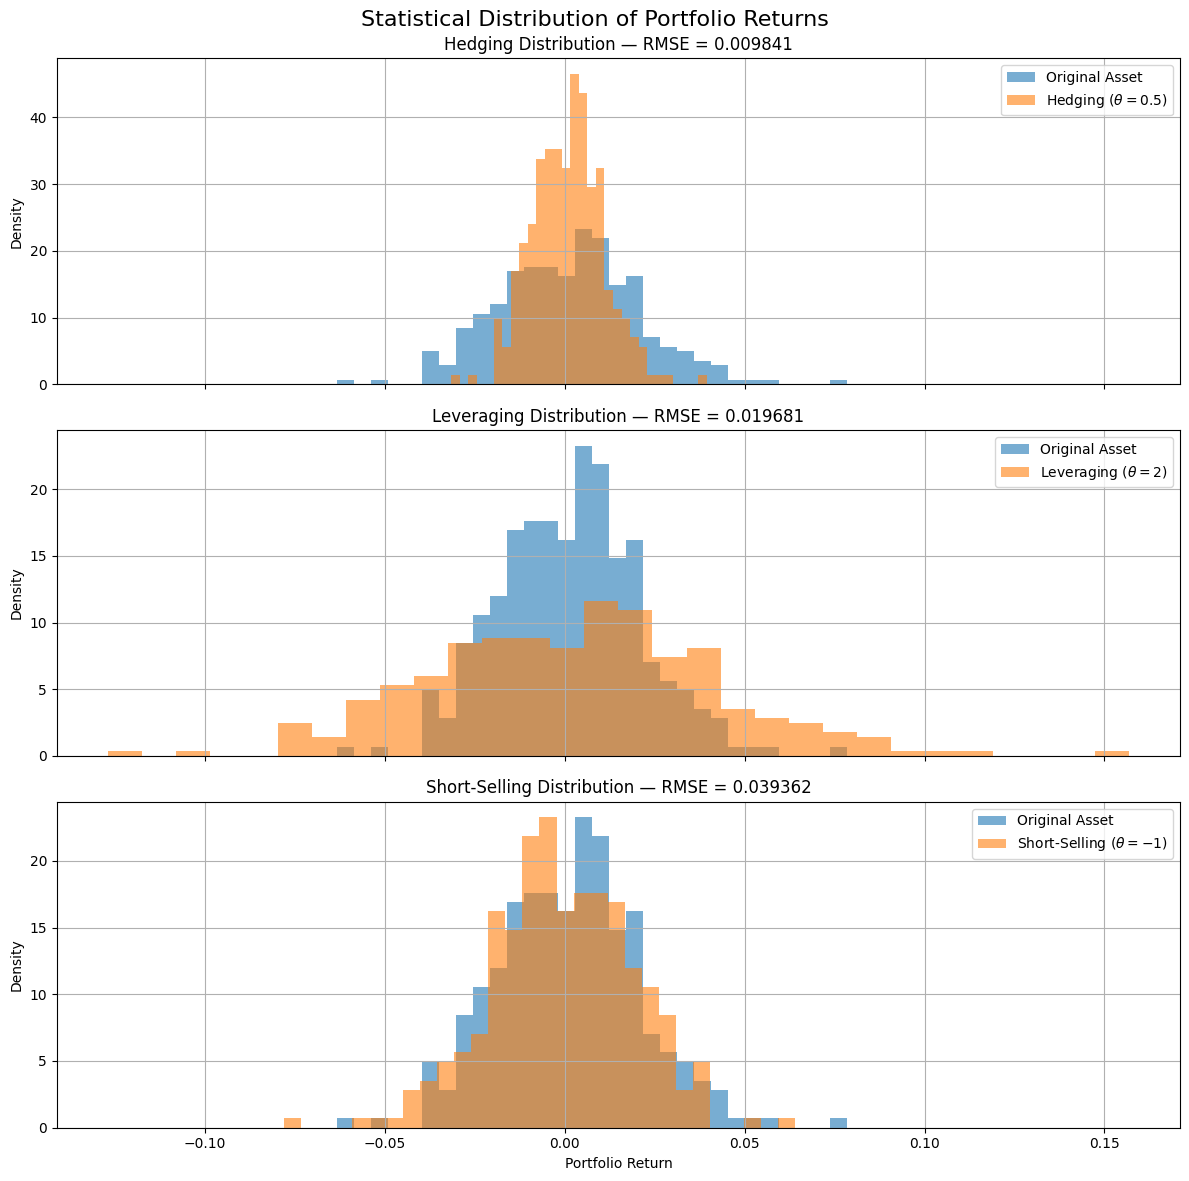

In [53]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12,12),
    sharex=True
)
axes[0].hist(
    r,
    bins=30,
    alpha=0.6,
    density=True,
    label='Original Asset'
)
axes[0].hist(
    portfolio_series["Hedging ($\\theta=0.5$)"],
    bins=30,
    alpha=0.6,
    density=True,
    label='Hedging ($\\theta=0.5$)'
)
axes[0].set_title(
    f"Hedging Distribution — RMSE = {rmse_hedging:.6f}"
)

axes[0].set_ylabel("Density")
axes[0].grid(True)
axes[0].legend()

axes[1].hist(
    r,
    bins=30,
    alpha=0.6,
    density=True,
    label='Original Asset'
)
axes[1].hist(
    portfolio_series["Leveraging ($\\theta=2$)"],
    bins=30,
    alpha=0.6,
    density=True,
    label='Leveraging ($\\theta=2$)'
)
axes[1].set_title(
    f"Leveraging Distribution — RMSE = {rmse_leveraging:.6f}"
)

axes[1].set_ylabel("Density")
axes[1].grid(True)
axes[1].legend()

axes[2].hist(
    r,
    bins=30,
    alpha=0.6,
    density=True,
    label='Original Asset'
)
axes[2].hist(
    portfolio_series["Short-Selling ($\\theta=-1$)"],
    bins=30,
    alpha=0.6,
    density=True,
    label='Short-Selling ($\\theta=-1$)'
)
axes[2].set_title(
    f"Short-Selling Distribution — RMSE = {rmse_short:.6f}"
)

axes[2].set_xlabel("Portfolio Return")
axes[2].set_ylabel("Density")
axes[2].grid(True)
axes[2].legend()


fig.suptitle(
    "Statistical Distribution of Portfolio Returns",
    fontsize=16
)

plt.tight_layout()

plt.show()

### Numerical Interpretation

The histograms reveal how different allocation strategies modify the statistical structure of the portfolio returns.

The distributions directly reflect the variance scaling law:

$$
\mathrm{Var}(c)
=
\theta^2\sigma^2.
$$

Consequently, the spread of the distributions changes according to the magnitude of the allocation parameter \(\theta\).


**Hedging Distribution**

The hedging strategy produces a visibly narrower distribution relative to the original asset.

This reduction in spread indicates lower volatility and smaller return fluctuations.

Since:

$$
0 < \theta < 1,
$$

the portfolio variance is reduced, causing the return distribution to become more concentrated around its mean value.
Geometrically, the centered return vector contracts toward the risk-free direction in the return space.


**Leveraging Distribution**

The leveraged portfolio exhibits a significantly wider distribution.

This behavior reflects the amplification of the return fluctuations caused by:

$$
\theta > 1.
$$

The larger spread indicates increased variance and higher statistical dispersion.

From a signal-energy perspective, leverage amplifies the quadratic energy of the centered portfolio vector.


*Short-Selling Distribution*

The short-selling distribution exhibits approximately the same spread magnitude as the original asset but with inverted exposure orientation.

Because:

$$
|\theta| = 1,
$$

the variance magnitude remains similar to the original portfolio.

However, the inversion of the return signal produces a mirrored statistical behavior relative to the original asset dynamics.

Geometrically, short-selling reflects the centered return vector across the origin of the return space.


**Overall Conclusion**

The experiments demonstrate that portfolio allocation modifies not only the temporal behavior of returns, but also their statistical geometry.

In particular:

- hedging compresses the return distribution;
- leveraging stretches the distribution;
- short-selling reverses the portfolio orientation while preserving variance magnitude.

These observations reinforce the interpretation of variance as a quadratic energy measure in the return space and show how affine portfolio transformations reshape the statistical structure of the returns.

## E) Affine Geometry of the Portfolio Space

### Introduction

This section investigates the geometric structure of the portfolio family using dimensionality reduction techniques based on Principal Component Analysis (PCA).

The objective is to demonstrate that all portfolios generated through different values of \(\theta\) belong to a low-dimensional affine manifold in the return space.

This experiment establishes a direct connection between portfolio allocation and affine geometry in vector spaces.

In [49]:
from sklearn.decomposition import PCA

theta_values = np.linspace(-2, 2, 30)
portfolio_vectors = []

for theta in theta_values:
    c = theta * r + (1 - theta) * ud
    portfolio_vectors.append(c)

portfolio_vectors = np.array(portfolio_vectors)
pca = PCA(n_components=2)

portfolio_projection = pca.fit_transform(portfolio_vectors)
explained_variance = pca.explained_variance_ratio_

pc1_variance = explained_variance[0]
pc2_variance = explained_variance[1]

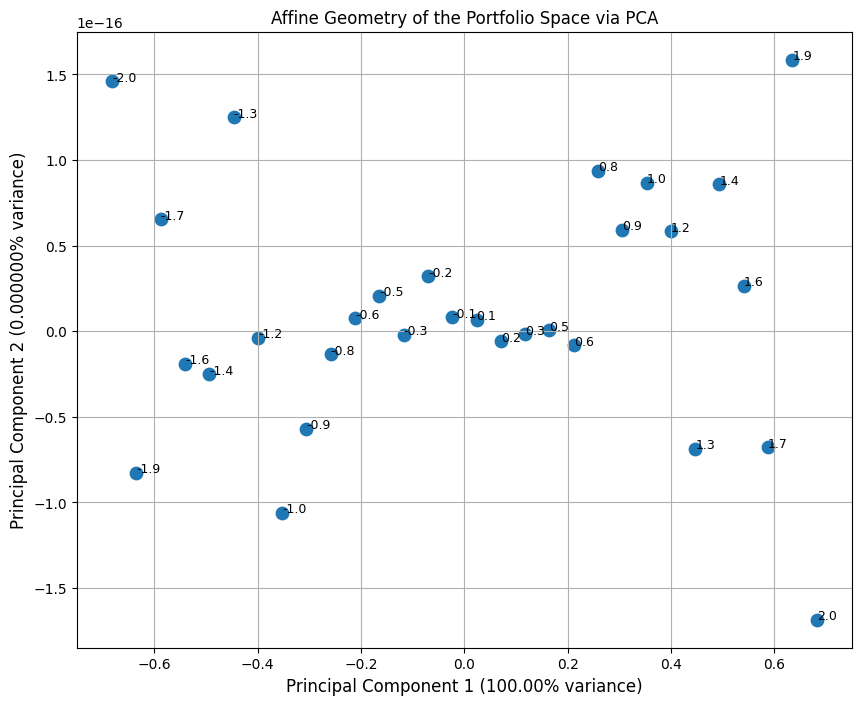

In [51]:
plt.figure(figsize=(10,8))

plt.scatter(
    portfolio_projection[:,0],
    portfolio_projection[:,1],
    s=80
)


for i, theta in enumerate(theta_values):
    plt.text(
        portfolio_projection[i,0],
        portfolio_projection[i,1],
        f"{theta:.1f}",
        fontsize=9
    )

plt.xlabel(
    f"Principal Component 1 ({pc1_variance*100:.2f}% variance)",
    fontsize=12
)
plt.ylabel(
    f"Principal Component 2 ({pc2_variance*100:.6f}% variance)",
    fontsize=12
)
plt.title(
    "Affine Geometry of the Portfolio Space via PCA"
)

plt.grid(True)
plt.show()

### Numerical Interpretation

The PCA projection reveals a remarkably strong low-dimensional geometric structure in the portfolio space.

The first principal component explains essentially all the variance of the dataset:

$$
\mathrm{PC1}
\approx
100\%
$$

while the second principal component contributes only a numerically negligible amount:

$$
\mathrm{PC2}
\approx
0\%.
$$

This result provides numerical evidence that the family of portfolios generated by varying the allocation parameter $(\theta)$ lies entirely along a one-dimensional affine manifold embedded in the high-dimensional return space:

$$
\mathbb{R}^T.
$$

---

## Affine Geometric Structure

The projected points align almost perfectly along a single horizontal direction in the PCA space.

This behavior directly confirms the analytical formulation:

$$
c
=
u_d\mathbf{1}
+
\theta(r-u_d\mathbf{1}),
$$

which defines the portfolio family as an affine line generated by:

- a translation component:

$$
u_d\mathbf{1},
$$

- and a single direction vector:

$$
r-u_d\mathbf{1}.
$$

Geometrically, the parameter $(\theta)$ controls movement along this affine direction.

---

## Interpretation of Positive and Negative Allocations

The PCA projection also clearly separates:

- positive values of $(\theta)$,
- and negative values of $(\theta)$.

Positive allocations appear on one side of the affine structure, while negative allocations appear on the opposite side.
This behavior reflects the orientation reversal induced by short-selling strategies.

In particular:

- $(\theta > 0)$ preserves the original asset orientation;
- $(\theta < 0)$ reverses the portfolio direction in the return space.

## Interpretation of the Second Principal Component

The small magnitude of the second principal component:

$$
\mathrm{PC2}
\sim
10^{-16},
$$

indicates that the residual variability orthogonal to the affine direction is essentially numerical noise caused by floating-point computations.

Therefore, the portfolio dataset is effectively rank-one after removing the affine offset.

This observation establishes a direct connection with fundamental concepts from linear algebra:

- affine subspaces;
- rank deficiency;
- intrinsic dimensionality;
- and low-rank structure.

## Overall Conclusion

The experiment confirms that the portfolio space possesses an intrinsically one-dimensional affine geometry.

Although each portfolio is represented as a vector in a high-dimensional space:

$$
\mathbb{R}^T,
$$

all admissible portfolios are generated through movement along a single dominant direction.
The PCA analysis therefore provides strong numerical evidence that portfolio allocation behaves as a low-rank affine transformation in the return space.

# Conclusion

This work investigated the geometric, statistical, and dynamical properties of portfolio allocation using affine combinations between a risky asset and a risk-free asset.

Through analytical derivations and computational simulations, we demonstrated that:

- the portfolio expected return evolves linearly with the allocation parameter $(\theta)$;
- the portfolio variance scales quadratically according to:
  
$$
\mathrm{Var}(c)=\theta^2\sigma^2;
$$

- and different allocation regimes naturally emerge, including:
  - hedging,
  - leveraging,
  - and short-selling.

The experiments further revealed that portfolio allocation can be interpreted geometrically as movement along a one-dimensional affine manifold embedded in a high-dimensional return space.

Using PCA analysis, we showed that the family of admissible portfolios possesses an intrinsically low-dimensional structure, reinforcing the connection between:

- affine geometry,
- dimensionality reduction,
- statistical dispersion,
- and financial portfolio dynamics.

Overall, the project established a direct relationship between concepts from:

- linear algebra,
- probability,
- geometry,
- and dynamical systems,

showing how portfolio allocation can be rigorously interpreted through the framework of affine transformations and low-rank vector-space representations.